In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_iris
iris=load_iris()
X=torch.tensor(iris.data , dtype=torch.float32)
y=torch.tensor(iris.target , dtype=torch.long)
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test=train_test_split(X , y , test_size=0.2 , random_state=101)

train_data = TensorDataset(X_train , y_train)
test_data=TensorDataset(X_test , y_test)

train_loader=DataLoader(train_data , batch_size=32 , shuffle=True)
test_loader=DataLoader(test_data , batch_size=len(test_data) , shuffle=False)

class ANNmodel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.input=nn.Linear(4,30)
        self.hidden=nn.ReLU()
        self.output=nn.Linear(30 , 3)
    
    def forward(self , x):
        
        x=self.input(x)
        x=self.hidden(x)
        x=self.output(x)
        
        return x 
    

def makemodel():
    model=ANNmodel()
    lr=0.01
    lossfn=nn.CrossEntropyLoss()
    optimizer=torch.optim.Adam(model.parameters() , lr=lr )
    
    return model , lossfn , optimizer 




In [16]:
model , lossfn , optimizer = makemodel()
print(model)
for name, param in model.named_parameters():
    print(name, param.shape)

ANNmodel(
  (input): Linear(in_features=4, out_features=30, bias=True)
  (hidden): ReLU()
  (output): Linear(in_features=30, out_features=3, bias=True)
)
input.weight torch.Size([30, 4])
input.bias torch.Size([30])
output.weight torch.Size([3, 30])
output.bias torch.Size([3])


In [ ]:
def trainmodel(model , lossfn ,optimizer , l1_rate):
    epochs=1000
    batch_acc=[]
    train_acc=[]
    test_acc=[]
    
    for i in range(epochs):
        
        model.train()
        
        for X, y in train_loader :
            
            y_train_preds=model(X)
            loss=lossfn(y_train_preds , y)
            
            l1_term=torch.tensor(0. , requires_grad=True)
            
            for name , weights in model.named_parameters():
                if 'bias' not in name :
                    l1_term=l1_term+torch.sum(torch.abs(weights))
                    
            
            #adding L1 to loss term 
            loss=loss+ (l1_rate*l1_term)
            
            #backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            #calculating accuracy 
            labels = torch.argmax(y_train_preds, dim=1)
            batch_acc.append(100*(labels == y).float().mean().item())
            #end of batch loop 
            
        #now train_acc
        train_acc.append(np.mean(batch_acc))
        
        #testing the model 
        model.eval()
        for X , y in test_loader :
            y_pred=model(X)
            labels = torch.argmax(y_pred, dim=1)
            test_acc.append(100*(labels == y).float().mean().item())
            
    return test_acc , train_acc 

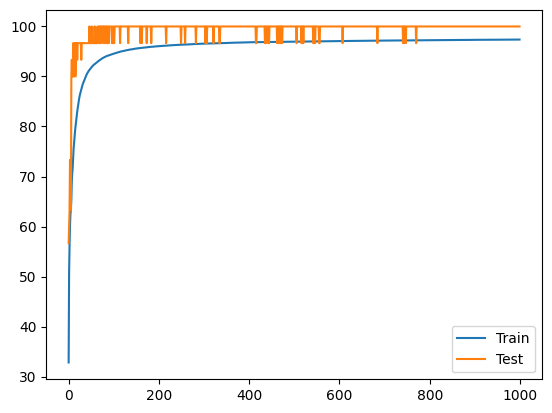

In [18]:
model , lossfn , optimizer =makemodel()
test_acc , train_acc = trainmodel(model , lossfn , optimizer , 0.01)
epochs=1000
plt.plot(range(epochs) , train_acc)
plt.plot(range(epochs) , test_acc)
plt.legend(['Train','Test'])

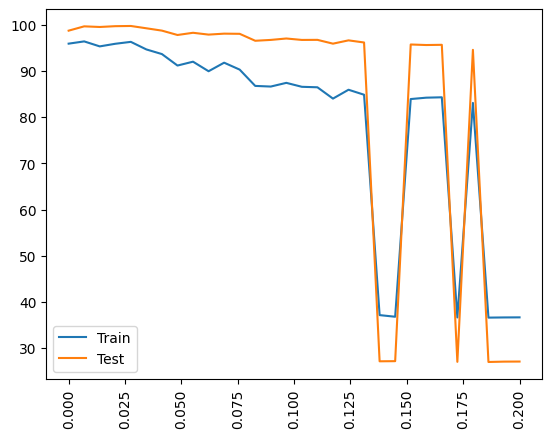

In [20]:
#EXPERIMENT 
l1_experiment=np.linspace(0 , 0.2 , 30)
final_test_acc=[]
final_train_acc=[]
for i in l1_experiment:
    model , lossfn , optimizer =makemodel()
    test_acc , train_acc = trainmodel(model , lossfn , optimizer , i)
    final_test_acc.append(np.mean(test_acc))
    final_train_acc.append(np.mean(train_acc))
    

plt.plot(l1_experiment , final_train_acc)
plt.plot(l1_experiment , final_test_acc)
plt.xticks(rotation=90)
plt.legend(['Train','Test'])